<a href="https://www.kaggle.com/code/miuskuish/space-missions-since-1957?scriptVersionId=243313859" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 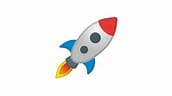 Summary of Space Missions Project 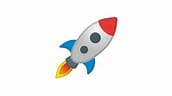
This project analyzes space missions from 1957 to 2020, focusing on various aspects such as mission outcomes, companies involved, and the geographical distribution of launch sites. The data is sourced from kaggle.

*Key Features of the Project:*


* Cleaned and prepared data on space missions, including companies, statuses, and launch locations

* Encoded key categories (e.g., mission and rocket status) for easier analysis

* Mapped launch sites to countries and created visuals showing global mission distribution

* Explored trends over time in successful and failed missions

* Ranked organizations by mission count and success rate

* Visualized insights using bar charts, stacked plots, and world map

# Data Loading and Initial Exploration

> Load Data and Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing
import seaborn as sns # lib for charts
import matplotlib.pyplot as plt # lib for plotting
import geopandas as gpd # worldmap

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/all-space-missions-from-1957/Space_Corrected.csv


> Define the number of *TOP entities to present in the analysis.
By default, the number is set to 10. This means the ranking graphics will plot the first 10 entities accordingly.

In [2]:
MAX_VALUE = 10    # Maximum of top entties to present

> Upload and take a glance at the top entries of the Space_Missions DataFrame from 1957

In [3]:
df = pd.read_csv("/kaggle/input/all-space-missions-from-1957/Space_Corrected.csv")
df.head(MAX_VALUE)

,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
5,5,5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success
6,6,6,Roscosmos,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Thu Jul 23, 2020 14:26 UTC",Soyuz 2.1a | Progress MS-15,StatusActive,48.5,Success
7,7,7,CASC,"LC-101, Wenchang Satellite Launch Center, China","Thu Jul 23, 2020 04:41 UTC",Long March 5 | Tianwen-1,StatusActive,NaN,Success
8,8,8,SpaceX,"SLC-40, Cape Canaveral AFS, Florida, USA","Mon Jul 20, 2020 21:30 UTC",Falcon 9 Block 5 | ANASIS-II,StatusActive,50.0,Success
9,9,9,JAXA,"LA-Y1, Tanegashima Space Center, Japan","Sun Jul 19, 2020 21:58 UTC",H-IIA 202 | Hope Mars Mission,StatusActive,90.0,Success


> Display the amount of non-null values, data types, and memory usage of our DataFrame (df)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Company Name    4324 non-null   object
 3   Location        4324 non-null   object
 4   Datum           4324 non-null   object
 5   Detail          4324 non-null   object
 6   Status Rocket   4324 non-null   object
 7    Rocket         964 non-null    object
 8   Status Mission  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


> Total of NaN values per Column

In [5]:
df.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
Company Name         0
Location             0
Datum                0
Detail               0
Status Rocket        0
 Rocket           3360
Status Mission       0
dtype: int64

# Data Cleaning and Validation

> Drop the redunant unsignificant Columns 'Unamed xx'

In [6]:
is_equal = df['Unnamed: 0.1'].equals(df['Unnamed: 0'])
if is_equal :
    df.drop(['Unnamed: 0.1','Unnamed: 0'], axis = 1, inplace=True) 

>  Make sure that Status Mission and Status Rocket are accurate

In [7]:
df.groupby(['Status Rocket','Status Mission', 'Company Name']).size().head(MAX_VALUE)


Status Rocket  Status Mission  Company Name
StatusActive   Failure         AEB             2
                               Arianespace     2
                               CASC            6
                               ExPace          1
                               Exos            1
                               ISA             7
                               ISRO            2
                               JAXA            1
                               KCST            1
                               Northrop        6
dtype: int64

> The Data Frame contains entries with the rocket status  "Active" but mission status 'not Successful'. To determine whether these entries are accurate, we should cross-reference these entries with reliable external sources, such as official space agency reports.

In [8]:
anomalies = df[(df['Status Rocket'] == 'StatusActive') & (df['Status Mission'] != 'Success')]
anomalies[['Company Name', 'Location', 'Datum', 'Detail']].head()

,Company Name,Location,Datum,Detail
11,ExPace,"Site 95, Jiuquan Satellite Launch Center, China","Fri Jul 10, 2020 04:17 UTC","Kuaizhou 11 | Jilin-1 02E, CentiSpace-1 S2"
15,Rocket Lab,"Rocket Lab LC-1A, M?hia Peninsula, New Zealand","Sat Jul 04, 2020 21:19 UTC",Electron/Curie | Pics Or It Didn??¦t Happen
27,Virgin Orbit,"Cosmic Girl, Mojave Air and Space Port, Califo...","Mon May 25, 2020 19:50 UTC",LauncherOne | Demo Flight
36,CASC,"LC-2, Xichang Satellite Launch Center, China","Thu Apr 09, 2020 11:46 UTC",Long March 3B/E | Nusantara Dua
43,CASC,"LC-201, Wenchang Satellite Launch Center, China","Mon Mar 16, 2020 13:34 UTC",Long March 7A | XJY-6


> Entry 15:  mission was actually successful and in colab with NASA. (source: https://spacenews.com/capstone-heads-to-the-moon/)
Hence, update our entry in the df to interpret this.
This should be done for each entry considered in df 'anomalies' 

In [9]:
# Update 'Status Mission' on Row 15
df.loc[15, 'Status Mission'] = 'Success'
print(df.iloc[15])

Company Name                                           Rocket Lab
Location          Rocket Lab LC-1A, M?hia Peninsula, New Zealand
Datum                                  Sat Jul 04, 2020 21:19 UTC
Detail                Electron/Curie | Pics Or It Didn??¦t Happen
Status Rocket                                        StatusActive
 Rocket                                                      7.5 
Status Mission                                            Success
Name: 15, dtype: object


> Format column 'Datum' into Pandas Date-Time.

In [10]:
df['Date Time'] = pd.to_datetime(df['Datum'], format= 'mixed', utc = True)

# Encoding Categorical Variables

> Encode 'Status Rocket': Identify and create a dictionary with the unique values from Status Rocket


In [11]:
rocket_status = df['Status Rocket'].unique()
count_rocket_status = {}
    
for unique in rocket_status:
    count_rocket_status[unique] = (df['Status Rocket'] == unique).sum()
    
print('Status Rocket contains the unique values:')
for unique, cnt in count_rocket_status.items():
    print(f'{unique}: {cnt} times')

encode_status_rocket = {
    'StatusActive': 0,
    'StatusRetired': 1,
}

df['Rocket Code'] = df['Status Rocket'].map(encode_status_rocket)

Status Rocket contains the unique values:
StatusActive: 790 times
StatusRetired: 3534 times


> Encode 'Status Mission': Identify and create a dictionary with the unique values from Status Mission


In [12]:
mission_status = df['Status Mission'].unique()
count_mission_status = {}

for unique in mission_status:
    count_mission_status[unique] = (df['Status Mission'] == unique).sum()

print('Status Mission contains the unique values:')
for unique, cnt in count_mission_status.items():
    print(f'{unique}: {cnt} times')

mission_encode = {
    'Success': 0,
    'Failure': 1,
    'Prelaunch Failure': 2,
    'Partial Failure': 3
}

df['Mission Code'] = df['Status Mission'].map(mission_encode)


Status Mission contains the unique values:
Success: 3880 times
Failure: 338 times
Prelaunch Failure: 4 times
Partial Failure: 102 times


# Splitting and Analyzing Location and Company Data

> Split and create a new column 'Country' out of 'Location'

In [13]:
df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())
print(df['Country'].head(MAX_VALUE))

0           USA
1         China
2           USA
3    Kazakhstan
4           USA
5         China
6    Kazakhstan
7         China
8           USA
9         Japan
Name: Country, dtype: object


> Check for invalid characters in the columns 'Country' and 'Company Name'

In [14]:
if (df['Country'].str.contains(r'[^\w\s]', regex=True).any()):
    print(df['Country'][df['Country'].str.contains(r'[^\w\s]', regex=True)])
else:
    print('Country has no invalid characters')

if (df['Company Name'].str.contains(r'[^\w\s]', regex=True).any()):
    print(df['Company Name'][df['Company Name'].str.contains(r'[^\w\s]', regex=True)])
else:
    print('Company Name has no invalid characters')

Country has no invalid characters
120             i-Space
3685            OKB-586
3730            OKB-586
3800    Arm??e de l'Air
3803    Arm??e de l'Air
3903    Arm??e de l'Air
3923    Arm??e de l'Air
Name: Company Name, dtype: object


> Update the Company Name 'Arm??e de l'Air'

In [15]:
df.loc[df['Company Name'] == "Arm??e de l'Air", 'Company Name'] = "Armée de l'Air"
print(df.iloc[3800])

Company Name                            Armée de l'Air
Location          Brigitte, Hammaguir, Algeria, France
Datum                       Wed Feb 15, 1967 10:06 UTC
Detail                          Diamant A | Diad?ªme 2
Status Rocket                            StatusRetired
 Rocket                                            NaN
Status Mission                                 Success
Date Time                    1967-02-15 10:06:00+00:00
Rocket Code                                          1
Mission Code                                         0
Country                                         France
Name: 3800, dtype: object


> Some Companies do not have a real Country as their Location. Make sure to update and map the Country for its Location accordingly.

In [16]:
country_name_mapping = {
    'USA': 'United States of America',
    'China': 'China',
    'Kazakhstan': 'Kazakhstan',
    'Japan': 'Japan',
    'Israel': 'Israel',
    'New Zealand': 'New Zealand',
    'Russia': 'Russia',
    'Shahrud Missile Test Site': 'Iran',
    'France': 'France',
    'Iran': 'Iran',
    'India': 'India',
    'New Mexico': 'United States of America',  
    'Yellow Sea': 'China',  
    'North Korea': 'North Korea',
    'Pacific Missile Range Facility': 'United States of America',  
    'Pacific Ocean': 'United States of America',  
    'South Korea': 'South Korea',
    'Barents Sea': "Russia",  
    'Brazil': 'Brazil',
    'Gran Canaria': 'Spain', 
    'Kenya': 'Kenya',
    'Australia': 'Australia'
}

df['Country'] = df['Country'].map(country_name_mapping)

> Group for each country, a list of companies that have operated there.

In [17]:
country_company_list = df.groupby('Country')['Company Name'].apply(lambda x: list(x.unique())).reset_index(name='Companies')
print(country_company_list.head(MAX_VALUE))

      Country                                          Companies
0   Australia                                [RAE, CECLES, AMBA]
1      Brazil                                              [AEB]
2       China  [CASC, ExPace, i-Space, OneSpace, Landspace, C...
3      France   [Arianespace, ESA, CNES, CECLES, Armée de l'Air]
4       India                                             [ISRO]
5        Iran                                        [IRGC, ISA]
6      Israel                                              [IAI]
7       Japan                              [JAXA, MHI, ISAS, UT]
8  Kazakhstan  [Roscosmos, Arianespace, ILS, VKS RF, Land Lau...
9       Kenya                                              [ASI]


> Group for each Country the total amount of missions


In [18]:
country_missions = df.groupby('Country').size().reset_index(name='Missions')
country_missions_sorted = country_missions.sort_values(by='Missions', ascending=False)

print(country_missions.head(MAX_VALUE))

      Country  Missions
0   Australia         6
1      Brazil         3
2       China       269
3      France       303
4       India        76
5        Iran        14
6      Israel        11
7       Japan       126
8  Kazakhstan       701
9       Kenya         9


In [19]:
country_nr = len(df['Country'].unique())
company_nr = len(df['Company Name'].unique())
mission_nr = sum(country_missions['Missions'])

print(f'There is a total of {country_nr} Countries, {company_nr} Companies and {mission_nr} Space Missions')

There is a total of 16 Countries, 56 Companies and 4324 Space Missions


> 

# Historical Overview of 'Status Mission'

> Group for each Year the total amount of Space Mission and Mission Status

In [20]:
df['Year'] = df['Date Time'].dt.year
status_mission_years = df.groupby(['Year', 'Status Mission']).size().reset_index(name='Count')
status_mission_years_company= status_mission_years.sort_values('Count', ascending=False)

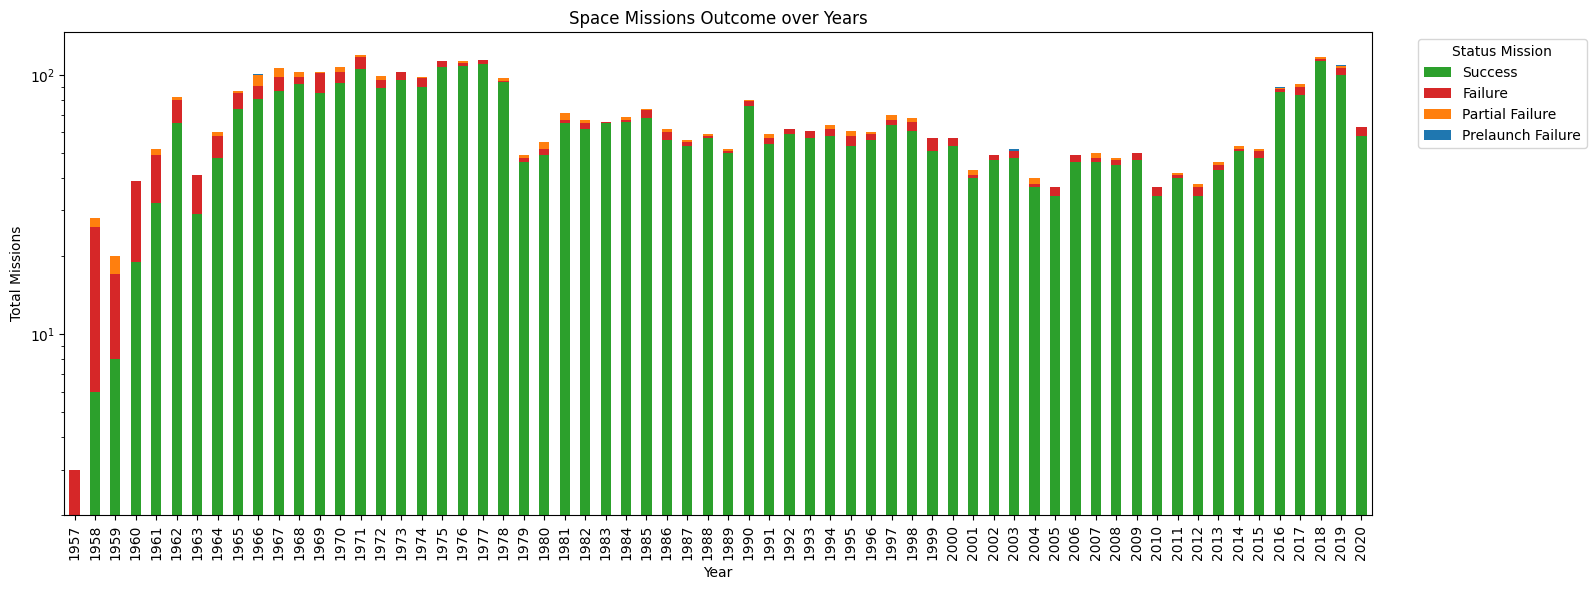

In [21]:
pivot_df1 = status_mission_years_company.pivot(index='Year', columns='Status Mission', values='Count')

pivot_df1['Total'] = pivot_df1.sum(axis=1)

status_colors = {
    'Success': '#2ca02c',  # Blue
    'Failure': '#d62728',  # Red
    'Partial Failure': '#ff7f0e',  # Orange
    'Prelaunch Failure': '#1f77b0'  # Green
}

pivot_df1 = pivot_df1[status_colors.keys()]
colors = [status_colors[status] for status in pivot_df1.columns]
pivot_df1.plot(kind='bar', stacked=True, figsize=(16, 6), color=colors, log=True)
plt.title('Space Missions Outcome over Years')
plt.xlabel('Year')
plt.ylabel('Total Missions')
plt.xticks(rotation=90)
plt.legend(title='Status Mission', bbox_to_anchor=(1.1, 1), loc='upper center', ncol=1)
plt.tight_layout()
plt.show()


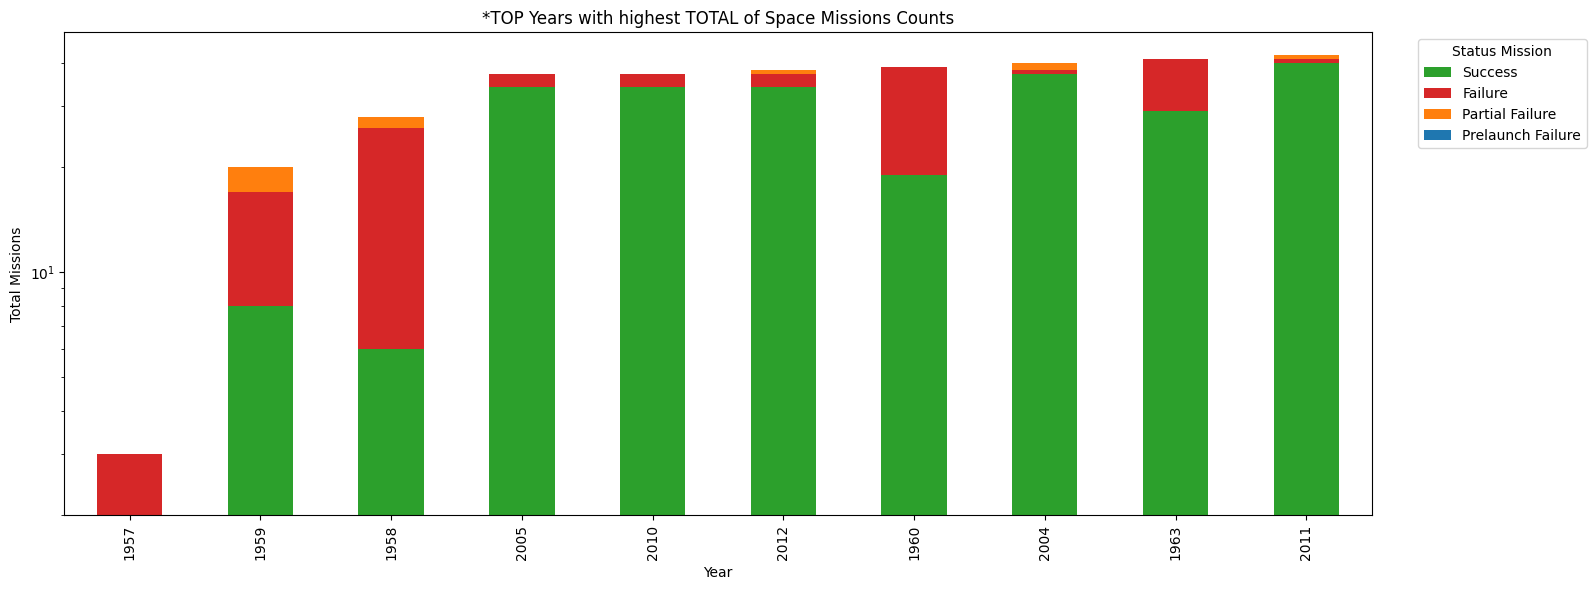

In [22]:
pivot_df = status_mission_years_company.pivot(index='Year', columns='Status Mission', values='Count')

pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('Total', ascending=True).drop(columns='Total')

pivot_df = pivot_df.head(MAX_VALUE)

palette = {'Success': '#2ca02c',  # Green
           'Failure': '#d62728',  # Red
           'Partial Failure': '#ff7f0e',  # Orange
           'Prelaunch Failure': '#1f77b0'  # Blue 
           }

pivot_df = pivot_df[palette.keys()]
colors = [palette[status] for status in pivot_df.columns]

pivot_df.plot(kind='bar', stacked=True, figsize=(16, 6), color=colors, log=True) #order
plt.title('*TOP Years with highest TOTAL of Space Missions Counts')
plt.xlabel('Year')
plt.ylabel('Total Missions')
plt.xticks(rotation=90)
plt.legend(title='Status Mission', bbox_to_anchor=(1.1, 1), loc='upper center', ncol=1)
plt.tight_layout()
plt.show()

# Comparative Analysis by Company

> Group for each Company the total amount of Space Mission and Mission Status

In [23]:
company_missions = df.groupby('Company Name')['Status Mission'].count().reset_index(name='Count')
company_missions_sorted = company_missions.sort_values('Count', ascending=False)['Company Name']

company_missions_by_status = df.groupby(['Company Name', 'Status Mission']).size().reset_index(name='Count')
company_missions_by_status.sort_values('Count', ascending=False, inplace=True)

success = company_missions_by_status[company_missions_by_status['Status Mission'] == 'Success']
success_missions = success.groupby('Company Name')['Count'].sum().reset_index()
success_missions.sort_values('Count', ascending=False, inplace=True)


no_success = company_missions_by_status[company_missions_by_status['Status Mission'] != 'Success']
no_success_missions = no_success.groupby('Company Name')['Count'].sum().reset_index()
no_success_missions.sort_values('Count', ascending=False, inplace=True)

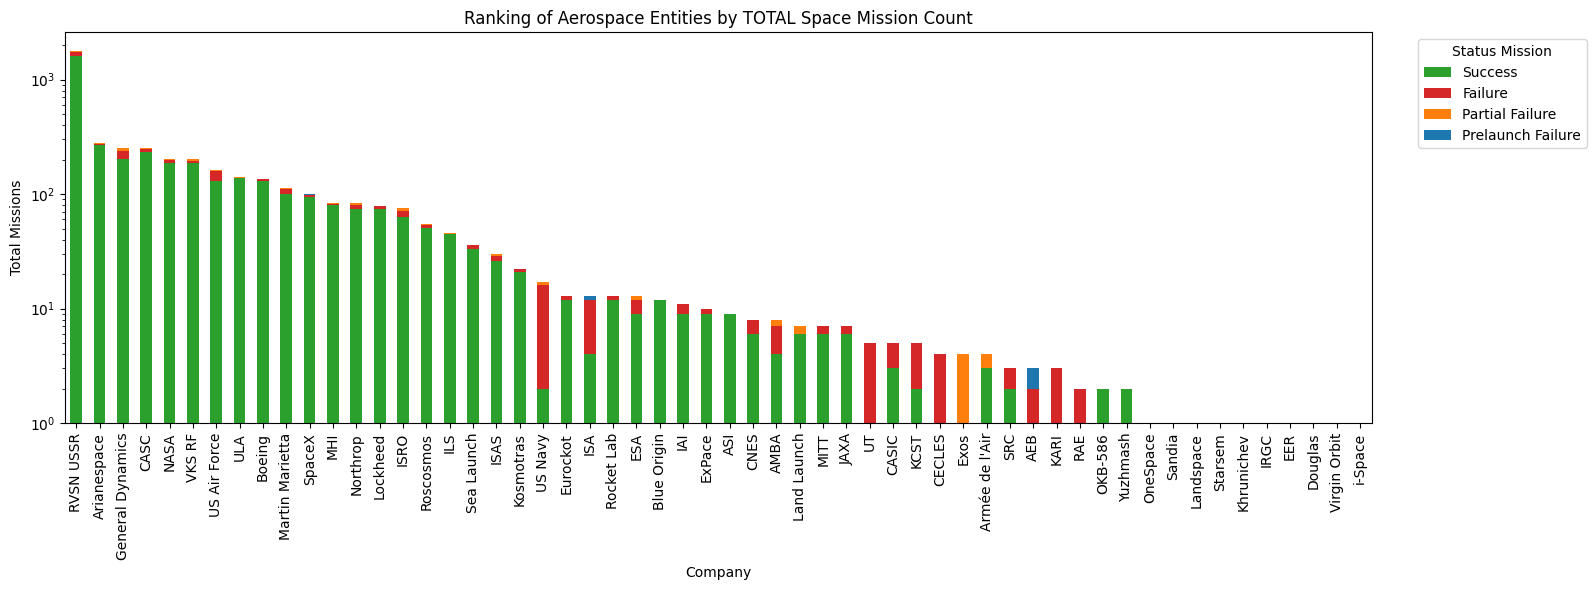

In [24]:
pivot_df = company_missions_by_status.pivot(index='Company Name', columns='Status Mission', values='Count')

pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('Total', ascending=False).drop(columns='Total')

palette = {'Success': '#2ca02c',  # Green
           'Failure': '#d62728',  # Red
           'Partial Failure': '#ff7f0e',  # Orange
           'Prelaunch Failure': '#1f77b0'  # Blue 
           }

pivot_df = pivot_df[palette.keys()]
colors = [palette[status] for status in pivot_df.columns]

pivot_df.plot(kind='bar', stacked=True, figsize=(16, 6), color=colors, log=True)

plt.title('Ranking of Aerospace Entities by TOTAL Space Mission Count')
plt.xlabel('Company')
plt.ylabel('Total Missions')
plt.xticks(rotation=90)
plt.legend(title='Status Mission', bbox_to_anchor=(1.1, 1), loc='upper center', ncol=1)
plt.tight_layout()
plt.show()


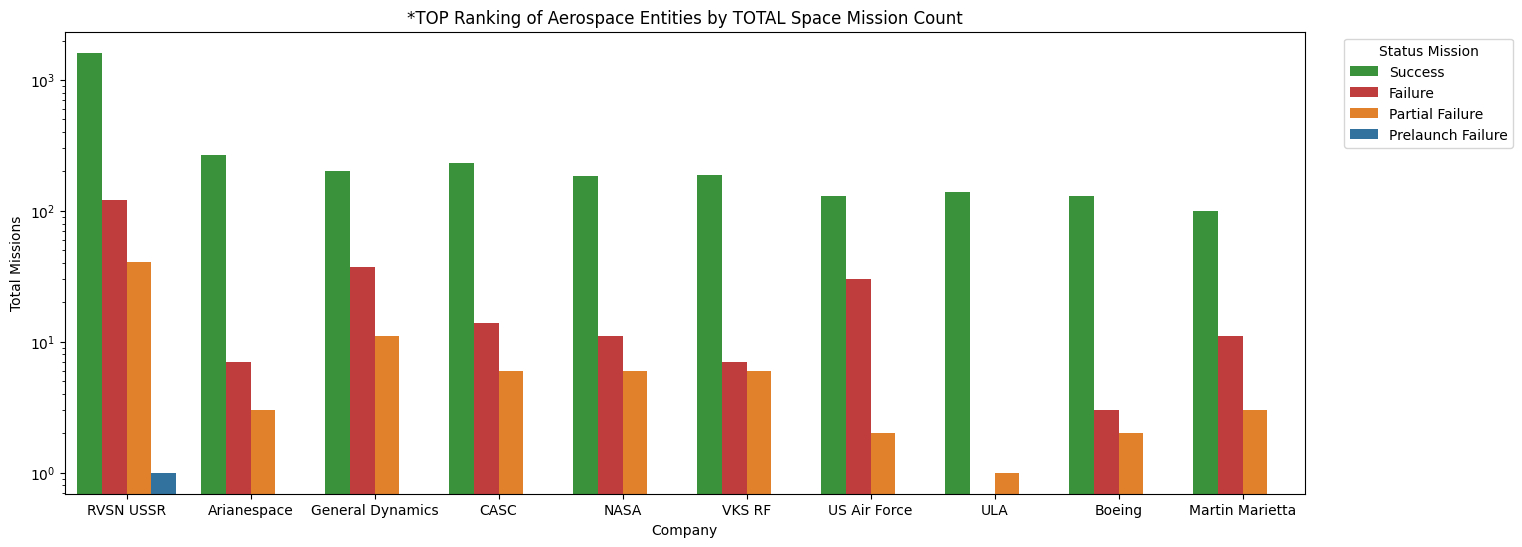

In [25]:
plt.figure(figsize=(16, 6))

palette = {'Success': '#2ca02c',  # Green
           'Failure': '#d62728',  # Red
           'Partial Failure': '#ff7f0e',  # Orange
           'Prelaunch Failure': '#1f77b0'  # Blue 
           }

sns.barplot(x='Company Name',
            y='Count',
            hue='Status Mission',
            palette=palette,
            data=company_missions_by_status,
            order=company_missions_sorted[0:MAX_VALUE]
           )

plt.yscale("log")
plt.title('*TOP Ranking of Aerospace Entities by TOTAL Space Mission Count')
plt.xlabel('Company')
plt.ylabel('Total Missions')
plt.legend(title='Status Mission', bbox_to_anchor=(1.1, 1), loc='upper center', ncol=1)
plt.show()

Text(0, 0.5, 'Successful Missions')

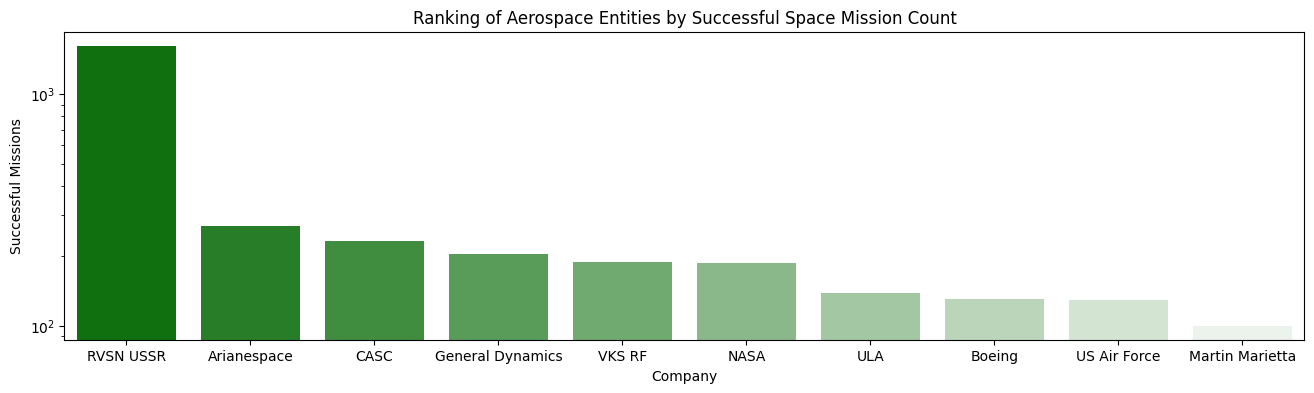

In [26]:
plt.figure(figsize=(16,4))
num_colors = len(success_missions.head(MAX_VALUE))
palette = sns.light_palette("green", n_colors=num_colors)
sns.barplot(x='Company Name', y='Count', data=success_missions.head(MAX_VALUE), palette= palette[::-1])
plt.yscale("log")
plt.title('Ranking of Aerospace Entities by Successful Space Mission Count')
plt.xlabel('Company')
plt.ylabel('Successful Missions')

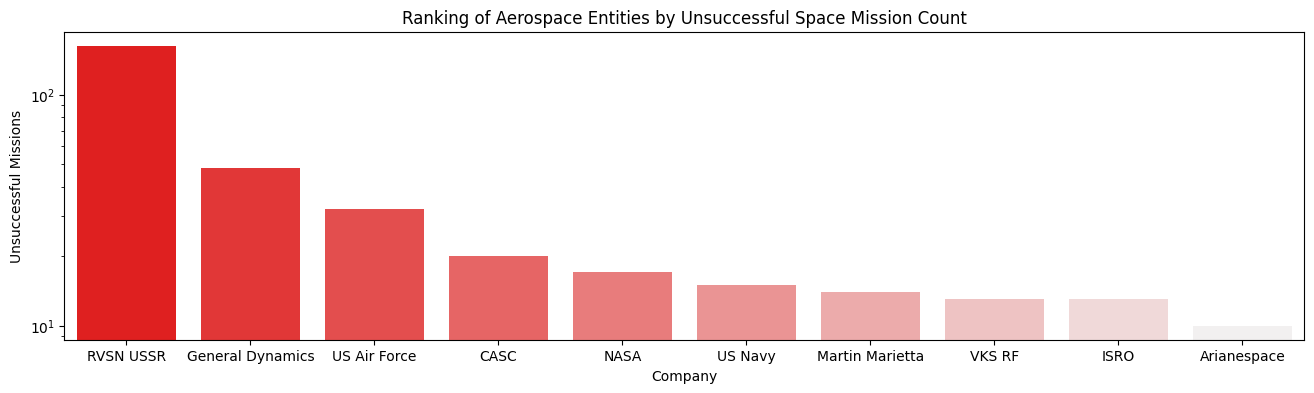

In [27]:
plt.figure(figsize=(16,4))
num_colors = len(no_success_missions.head(MAX_VALUE))
palette = sns.light_palette("red", n_colors=num_colors)
sns.barplot(x='Company Name', y='Count', data=no_success_missions.head(MAX_VALUE), palette=palette[::-1])
plt.yscale("log")
plt.title('Ranking of Aerospace Entities by Unsuccessful Space Mission Count')
plt.xlabel('Company')
plt.ylabel('Unsuccessful Missions')
plt.show()

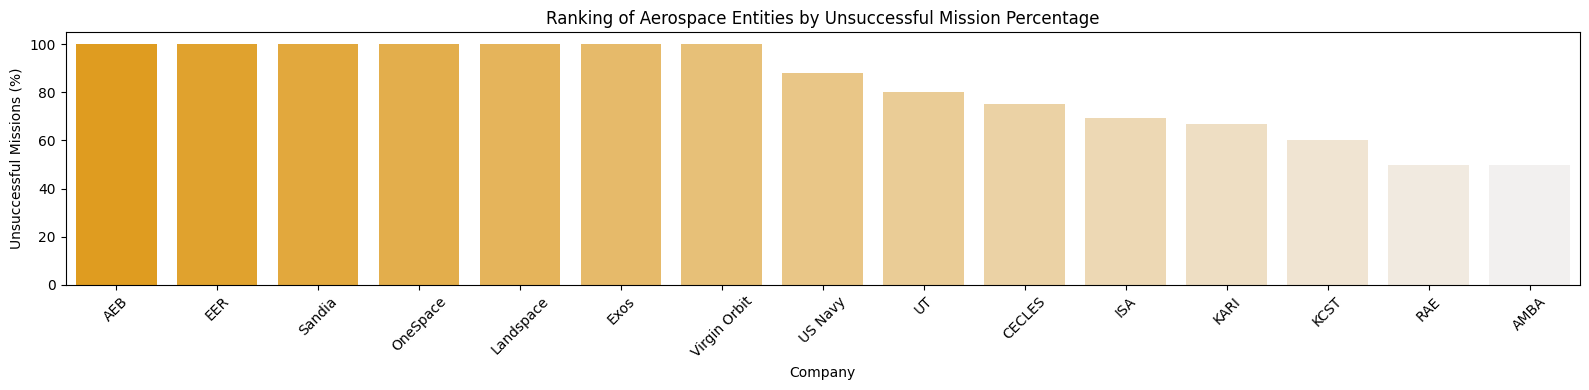

In [28]:
company_totals = df.groupby('Company Name').size().reset_index(name='Total')
company_failures = df[df['Status Mission'] != 'Success'].groupby('Company Name').size().reset_index(name='Failures')

failure_rates = pd.merge(company_totals, company_failures, on='Company Name', how='inner')
failure_rates['Fail_Percent'] = 100 * failure_rates['Failures'] / failure_rates['Total']

MAX_VALUE = 15  
top_failures = failure_rates.sort_values(by='Fail_Percent', ascending=False).head(MAX_VALUE)



plt.figure(figsize=(16, 4))
palette = sns.light_palette("orange", n_colors=len(top_failures))

sns.barplot(x='Company Name', y='Fail_Percent', data=top_failures, palette=palette[::-1])
plt.title('Ranking of Aerospace Entities by Unsuccessful Mission Percentage')
plt.xlabel('Company')
plt.ylabel('Unsuccessful Missions (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# HeatMap for Total Missions by Country

> Show the distribution of total space missions by country. 

/tmp/ipykernel_19/452328106.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


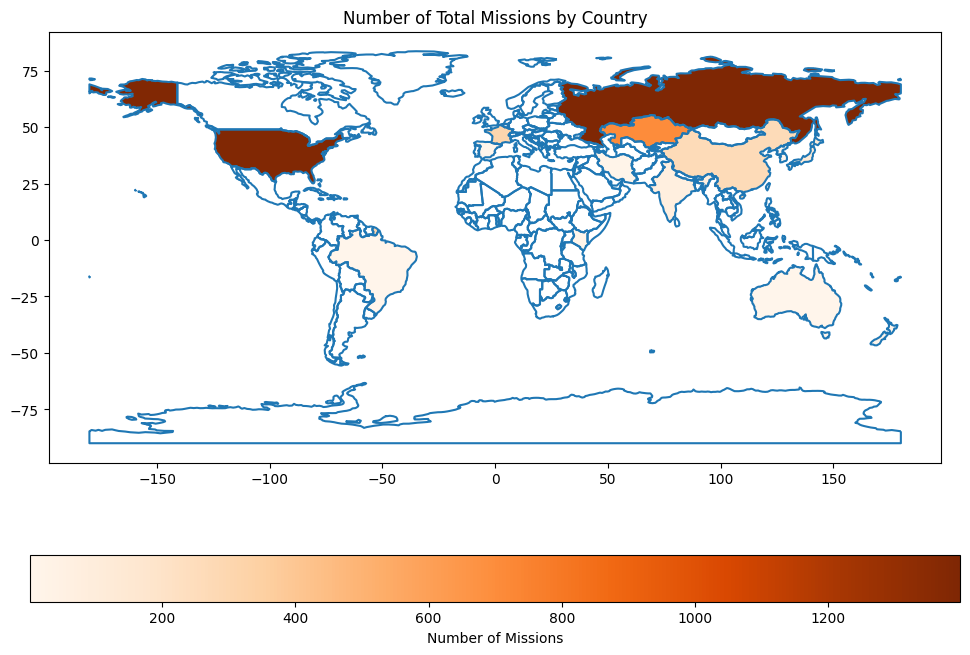

In [29]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world.merge(country_missions, how='left', left_on='name', right_on='Country')

# color palette
num_colors = len(world['Missions'].unique())
orange_palette = sns.color_palette("Oranges", num_colors)


fig, ax = plt.subplots(1, 1, figsize=(12, 8))
world.boundary.plot(ax=ax)
world.plot(column='Missions', ax=ax, legend=True, 
           legend_kwds={'label': "Number of Missions",
                        'orientation': "horizontal"},
           cmap='Oranges')

plt.title('Number of Total Missions by Country')
plt.show()
